In [4]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [2]:
# Read in the tj.dat file for both the capacitive and inductive devices
data_cap = pd.read_csv("Data/Default IS/tj.dat", sep=r'\s+')
data_ind = pd.read_csv("Data/Inductive IS/tj.dat", sep=r'\s+')

## Perfect Curve Test

The goal here is to verify whether the Groningen method, the linear method, or the checkerboard method can correctly identify the number of lifetimes in perfect curves


#### Specific Case Study: 3 Capacitive effects

In [7]:
# Select the time range we're going to use
time = data_cap['t'].iloc[1:].values

[]

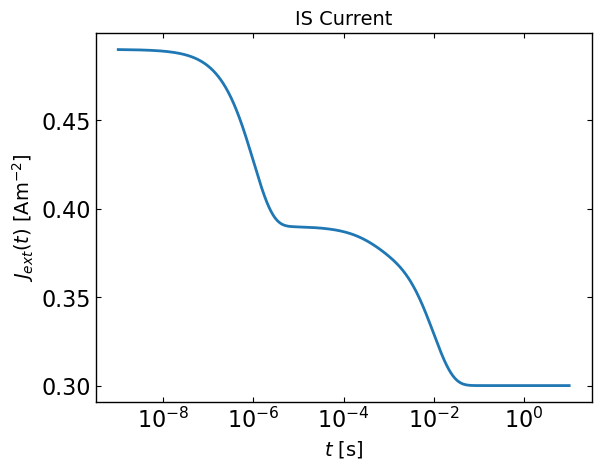

In [36]:
# Generate a curve with 3 arbitrary lifetimes 
tau_true = [1e-6, 4e-4, 1e-2]
U_true = [0.1, 0.01, 0.08]
offset_true = 0.3
DRT_curve_true = drt.DRT_curve(time, U_true, tau_true, offset_true)
# DRT_curve_manual = offset_true
# for i in range(len(U_true)):
#     DRT_curve_manual += U_true[i] * np.exp(-time/tau_true[i])


plt.plot(time, DRT_curve_true)
# plt.plot(time, DRT_curve_manual)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.plot()

In [20]:
# Fit with the Groningen Method for a variety of lifetimes
# Use BIC for varying levels of the Groningen fit
drt_scaled = (DRT_curve_true - DRT_curve_true.min())/(DRT_curve_true.max() - DRT_curve_true.min())
offset0 = DRT_curve_true.min()

# Set iteration variables
m_values = range(1,11)
fits_gr = []

for m in m_values:
    # Set the initial guesses for parameters that do depend on m
    U0 = (DRT_curve_true.max()-offset0)*np.ones(m)/m
    tau0 = np.geomspace(time[0], time[-1], m)

    # Apply the fit
    fit = drt.fit_DRT_curve(time, DRT_curve_true, U0, tau0, offset0=offset0) 

    # Add to collection of fits
    fits_gr.append(fit)

/home/josh-edmundson/Documents/SIMsalabim-installs/pySIMsalabim/Notebooks/Projects/Den RT/Perfect Curve Test/../../../../pySIMsalabim/aux_funcs/time_domain_DRT.py:148: RuntimeWarning: overflow encountered in exp
  calculated_DRT_curve = (U @ np.exp(-np.outer(1/tau, t))) + offset
/home/josh-edmundson/miniconda3/envs/pySIMsalabim/lib/python3.13/site-packages/scipy/optimize/_lsq/trf.py:527: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)
/home/josh-edmundson/Documents/SIMsalabim-installs/pySIMsalabim/Notebooks/Projects/Den RT/Perfect Curve Test/../../../../pySIMsalabim/aux_funcs/time_domain_DRT.py:148: RuntimeWarning: invalid value encountered in matmul
  calculated_DRT_curve = (U @ np.exp(-np.outer(1/tau, t))) + offset


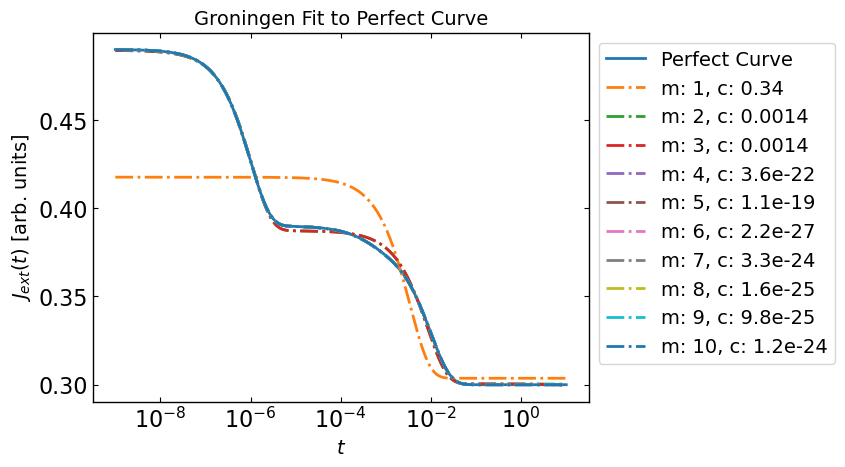

In [ ]:
# Plot results
plt.plot(time, DRT_curve_true, label='Perfect Curve')

for i in range(len(fits_gr)):
    fit = fits_gr[i]
    plt.plot(time, fit.DRT_curve, linestyle='-.', label=f"m: {fit.m}, c: {fit.cost:.2}")

plt.xscale('log')
plt.ylabel('$J_{ext}(t)$ [arb. units]')
plt.xlabel('$t$')
plt.title(f"Groningen Fit to Perfect Curve")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.show()

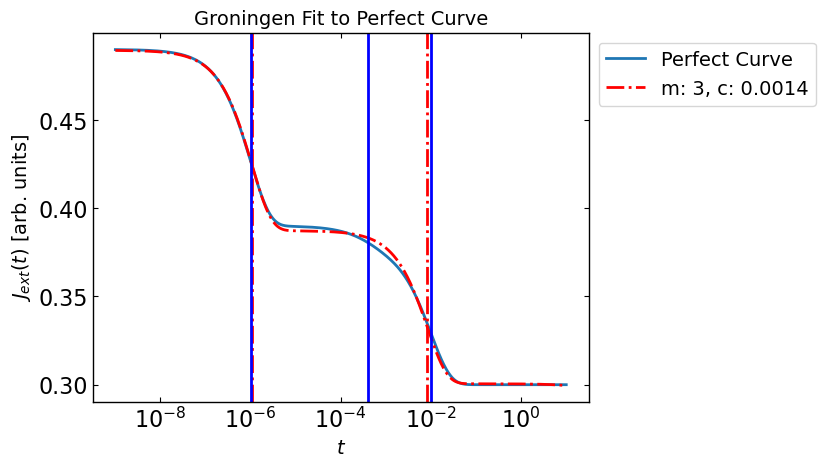

In [39]:
# Plot results
plt.plot(time, DRT_curve_true, label='Perfect Curve')

fit = fits_gr[2]
plt.plot(time, fit.DRT_curve, linestyle='-.', color='red', label=f"m: {fit.m}, c: {fit.cost:.2}")

for lifetime in fit.tau:
    plt.axvline(lifetime, linestyle='-.', color='red')

for lifetime in tau_true: 
    plt.axvline(lifetime, color='blue')


plt.xscale('log')
plt.ylabel('$J_{ext}(t)$ [arb. units]')
plt.xlabel('$t$')
plt.title(f"Groningen Fit to Perfect Curve")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [25]:
# Fit with the Groningen Method for a variety of lifetimes
drt_scaled = (DRT_curve_true - DRT_curve_true.min())/(DRT_curve_true.max() - DRT_curve_true.min())

# Set iteration variables
m_values = range(1,11)
fits_gr_scaled = []

for m in m_values:
    # Set the initial guesses for parameters that do depend on m
    U0 = np.ones(m)/m
    tau0 = np.geomspace(time[0], time[-1], m)

    # Apply the fit
    fit = drt.fit_DRT_curve(time, drt_scaled, U0, tau0, offset0=offset0) 

    # Add to collection of fits
    fits_gr_scaled.append(fit)

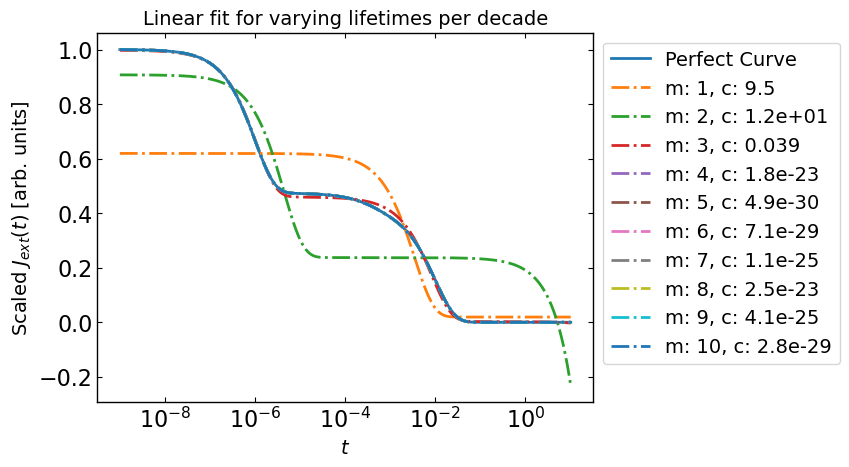

In [28]:
# Plot results
plt.plot(time, drt_scaled, label='Perfect Curve')

for i in range(len(fits_gr_scaled)):
    fit = fits_gr_scaled[i]
    plt.plot(time, fit.DRT_curve, linestyle='-.', label=f"m: {fit.m}, c: {fit.cost:.2}")

plt.xscale('log')
plt.ylabel('Scaled $J_{ext}(t)$ [arb. units]')
plt.xlabel('$t$')
plt.title(f"Linear fit for varying lifetimes per decade")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.show()

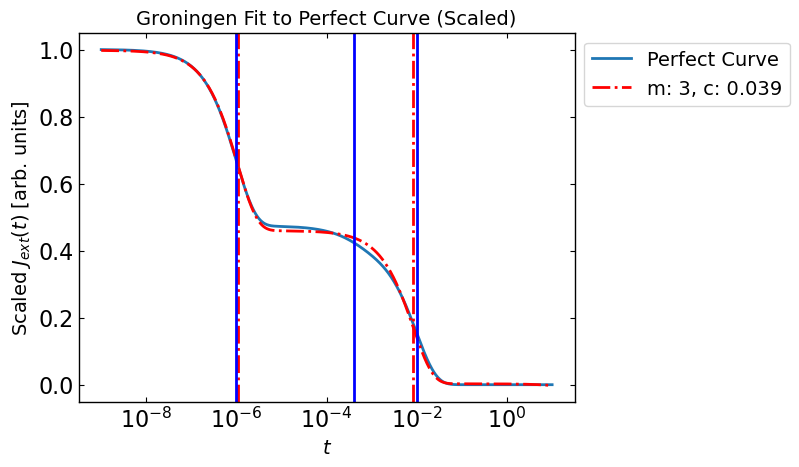

In [42]:
# Plot results
plt.plot(time, drt_scaled, label='Perfect Curve')

fit = fits_gr_scaled[2]
plt.plot(time, fit.DRT_curve, linestyle='-.', color='red', label=f"m: {fit.m}, c: {fit.cost:.2}")

for lifetime in fit.tau:
    plt.axvline(lifetime, linestyle='-.', color='red')

for lifetime in tau_true: 
    plt.axvline(lifetime, color='blue')


plt.xscale('log')
plt.ylabel('Scaled $J_{ext}(t)$ [arb. units]')
plt.xlabel('$t$')
plt.title(f"Groningen Fit to Perfect Curve (Scaled)")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.show()

In [43]:
# Try the linear method for a grid that exactly matches the time spacing 
U_scale_factor = DRT_curve_true.max() - DRT_curve_true.min()
fit_linear = drt.fit_DRT_curve_linear(time, DRT_curve_true, time, U_scale_factor=DRT_curve_true.max(), offset=DRT_curve_true.min(), backend='torch')

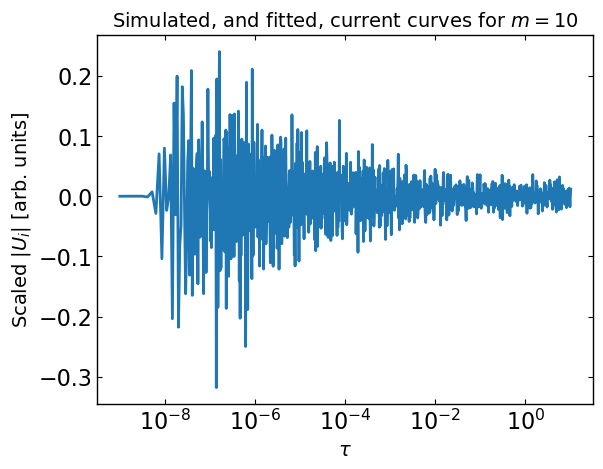

In [44]:
plt.plot(time, fit_linear.U)
plt.xscale('log')
plt.ylabel('Scaled $|U_i|$ [arb. units]')
plt.xlabel('$\\tau$')
plt.title(f"Simulated, and fitted, current curves for $m={m}$")
plt.show()

In [45]:
# Try the linear method for a grid that exactly matches the time spacing 
U_scale_factor = DRT_curve_true.max() - DRT_curve_true.min()
fit_linear = drt.fit_DRT_curve_linear(time, DRT_curve_true, time, U_scale_factor=DRT_curve_true.max(), offset=DRT_curve_true.min(), backend='torch', bounds=(0, np.inf))

KeyboardInterrupt: 